## Aspect-Based Sentiment Analysis – Google Discontinued Products

Using `langextract` to extract structured aspect-sentiment triples from YouTube comments for Google Stadia, Google Glass, and Google+.

Aspects: Product Quality, Price/Value, Market Demand, Adoption Ability, Timing/Innovation

In [ ]:
import os
os.environ['GOOGLE_API_KEY'] = 

In [2]:
import os
import re
import json
import time
import csv
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from dotenv import load_dotenv

import langextract as lx
from langextract import data as lx_data

load_dotenv()
API_KEY = os.environ.get('GOOGLE_API_KEY') or os.environ.get('GEMINI_API_KEY')
MODEL_ID = 'gemini-2.5-flash-lite'

if not API_KEY:
    raise ValueError('Set GOOGLE_API_KEY in your .env file')
print('API key loaded, model:', MODEL_ID)

API key loaded, model: gemini-2.5-flash-lite


### Load and sample the YouTube comment data

In [3]:
def load_csv(path, product, period):
    df = pd.read_csv(path)
    df['product'] = product
    df['period'] = period
    return df

frames = [
    load_csv('old_stadia_youtube_comments_raw.csv',          'stadia',       'before'),
    load_csv('recent_stadia_youtube_comments_raw.csv',       'stadia',       'after'),
    load_csv('old_google_glass_youtube_comments_raw.csv',    'google_glass', 'before'),
    load_csv('recent_google_glass_youtube_comments_raw.csv', 'google_glass', 'after'),
    load_csv('old_plus_youtube_comments_raw.csv',            'google_plus',  'before'),
    load_csv('recent_plus_youtube_comments_raw.csv',         'google_plus',  'after'),
]
df = pd.concat(frames, ignore_index=True)
df = df[df['comment'].notna()]
df['comment'] = df['comment'].astype(str).str.strip()
df = df[df['comment'].apply(lambda x: len(x.split())) >= 5].reset_index(drop=True)

# sample 25 per product per period to keep API cost low
sample_df = (
    df.groupby(['product', 'period'], group_keys=False)
    .apply(lambda g: g.sample(min(25, len(g)), random_state=42))
    .reset_index(drop=True)
)
print('sample size:', len(sample_df))
print(sample_df.groupby(['product','period']).size())

sample size: 150
product       period
google_glass  after     25
              before    25
google_plus   after     25
              before    25
stadia        after     25
              before    25
dtype: int64


### ABSA prompt and few-shot examples

All LLM calls go through `lx.extract()` with `lx.data.ExampleData` — no direct API calls.

In [4]:
ABSA_PROMPT = '''\
You are performing Aspect-Based Sentiment Analysis on a YouTube comment about a discontinued Google product.

For each product aspect mentioned, extract one record with:
  - aspect       : the specific feature being discussed. Must be one of:
                   Product Quality, Price/Value, Market Demand, Adoption Ability, Timing/Innovation
  - sentiment    : exactly one of {Positive, Negative, Neutral}
  - justification: a short verbatim snippet from the comment supporting the sentiment

Handle sarcasm carefully — assign sentiment based on the underlying meaning, not literal words.
One comment can have multiple aspect extractions.
'''

ABSA_EXAMPLES = [
    lx_data.ExampleData(
        text='The hardware was genuinely good but nobody wanted to pay a monthly fee just to play games they dont own.',
        extractions=[
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='hardware was genuinely good',
                attributes={'aspect': 'Product Quality', 'sentiment': 'Positive',
                            'justification': 'hardware was genuinely good'}
            ),
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='nobody wanted to pay a monthly fee',
                attributes={'aspect': 'Price/Value', 'sentiment': 'Negative',
                            'justification': 'nobody wanted to pay a monthly fee just to play games they dont own'}
            ),
        ]
    ),
    lx_data.ExampleData(
        text='Google Glass was so ahead of its time. The market just wasnt ready for it in 2013.',
        extractions=[
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='so ahead of its time',
                attributes={'aspect': 'Timing/Innovation', 'sentiment': 'Positive',
                            'justification': 'Google Glass was so ahead of its time'}
            ),
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='market just wasnt ready for it',
                attributes={'aspect': 'Market Demand', 'sentiment': 'Negative',
                            'justification': 'The market just wasnt ready for it in 2013'}
            ),
        ]
    ),
    lx_data.ExampleData(
        text='Oh great, another Google product I got used to is gone. Classic Google, amazing idea, zero commitment.',
        extractions=[
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='amazing idea, zero commitment',
                attributes={'aspect': 'Timing/Innovation', 'sentiment': 'Neutral',
                            'justification': 'amazing idea but zero commitment — sarcasm about discontinuation'}
            ),
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='another Google product I got used to is gone',
                attributes={'aspect': 'Adoption Ability', 'sentiment': 'Negative',
                            'justification': 'product discontinued after users adopted it'}
            ),
        ]
    ),
    lx_data.ExampleData(
        text='Stadia actually ran games super smoothly, the lag was way less than people said. But at that price point nobody was going to switch from console.',
        extractions=[
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='ran games super smoothly, the lag was way less',
                attributes={'aspect': 'Product Quality', 'sentiment': 'Positive',
                            'justification': 'ran games super smoothly, the lag was way less than people said'}
            ),
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='at that price point nobody was going to switch',
                attributes={'aspect': 'Price/Value', 'sentiment': 'Negative',
                            'justification': 'at that price point nobody was going to switch from console'}
            ),
            lx_data.Extraction(
                extraction_class='aspect_sentiment',
                extraction_text='nobody was going to switch from console',
                attributes={'aspect': 'Market Demand', 'sentiment': 'Negative',
                            'justification': 'nobody was going to switch from console — low market adoption'}
            ),
        ]
    ),
]

### Retry helper for Gemini 429 rate limit errors

In [5]:
def lx_extract_with_retry(max_retries=5, **kwargs):
    delay = 1.0
    for attempt in range(max_retries):
        try:
            return lx.extract(**kwargs)
        except Exception as e:
            msg = str(e)
            if '429' not in msg and 'RESOURCE_EXHAUSTED' not in msg:
                raise
            import re as _re
            m = _re.search(r"retryDelay'?\s*[:=]\s*'?(\d+(?:\.\d+)?)s", msg)
            wait = min(float(m.group(1)) + 1.0, 90.0) if m else delay
            delay = min(delay * 2, 60)
            print(f'429 hit attempt {attempt+1}/{max_retries}, sleeping {wait:.0f}s...')
            time.sleep(wait)
    return lx.extract(**kwargs)

### Run ABSA on sampled comments

In [6]:
def run_absa(text):
    return lx_extract_with_retry(
        text_or_documents=text,
        prompt_description=ABSA_PROMPT,
        examples=ABSA_EXAMPLES,
        model_id=MODEL_ID,
        api_key=API_KEY,
        extraction_passes=1,
        max_char_buffer=1000,
        max_workers=2,
        show_progress=False,
    )

all_records = []
total = len(sample_df)

for i, row in sample_df.iterrows():
    try:
        doc = run_absa(row['comment'])
        extractions = getattr(doc, 'extractions', None) or []
        for ext in extractions:
            attrs = getattr(ext, 'attributes', {}) or {}
            all_records.append({
                'comment_id': i,
                'product':    row['product'],
                'period':     row['period'],
                'comment':    row['comment'][:120],
                'aspect':     attrs.get('aspect', '').strip(),
                'sentiment':  attrs.get('sentiment', 'Neutral').strip().capitalize(),
                'justification': attrs.get('justification', getattr(ext, 'extraction_text', '')),
            })
    except Exception as e:
        print(f'skipped row {i}: {e}')
        continue
    if (i + 1) % 25 == 0 or i + 1 == total:
        print(f'processed {i+1}/{total} — {len(all_records)} triples so far')

results_df = pd.DataFrame(all_records)
print('\ntotal aspect-sentiment triples:', len(results_df))
print(results_df.head())

processed 25/150 — 38 triples so far


processed 50/150 — 69 triples so far


processed 75/150 — 102 triples so far


processed 100/150 — 189 triples so far


processed 125/150 — 234 triples so far


processed 150/150 — 268 triples so far

total aspect-sentiment triples: 268
   comment_id       product period  \
0           0  google_glass  after   
1           0  google_glass  after   
2           1  google_glass  after   
3           2  google_glass  after   
4           2  google_glass  after   

                                             comment            aspect  \
0  Being one of the first 350 on Google+, I was o...   Product Quality   
1  Being one of the first 350 on Google+, I was o...  Adoption Ability   
2  Neither one of these problems seem to be a pro...   Product Quality   
3  I want those apple glasses now just so I can i...  Adoption Ability   
4  I want those apple glasses now just so I can i...     Market Demand   

  sentiment                                      justification  
0  Negative  camera was constantly on in the first release,...  
1  Negative  privacy concerns about Google monitoring user ...  
2  Positive                    problems are no longer a

### Save extractions to CSV and JSON

In [7]:
results_df.to_csv('absa_extractions.csv', index=False)
results_df.to_json('absa_extractions.json', orient='records', indent=2)
print('saved absa_extractions.csv and absa_extractions.json')

saved absa_extractions.csv and absa_extractions.json


### Aggregate: sentiment counts by aspect and product

In [8]:
agg = results_df.groupby(['product', 'aspect', 'sentiment']).size().reset_index(name='count')
print(agg.sort_values(['product','aspect','sentiment']).to_string(index=False))

     product            aspect sentiment  count
google_glass  Adoption Ability  Negative      3
google_glass  Adoption Ability   Neutral      2
google_glass  Adoption Ability  Positive      6
google_glass     Market Demand  Negative     10
google_glass     Market Demand   Neutral      3
google_glass     Market Demand  Positive      5
google_glass       Price/Value  Negative      1
google_glass       Price/Value   Neutral      1
google_glass   Product Quality  Negative     14
google_glass   Product Quality   Neutral      2
google_glass   Product Quality  Positive      9
google_glass Timing/Innovation  Negative      4
google_glass Timing/Innovation   Neutral      1
google_glass Timing/Innovation  Positive      8
 google_plus  Adoption Ability  Negative     13
 google_plus  Adoption Ability   Neutral      3
 google_plus  Adoption Ability  Positive      6
 google_plus     Market Demand  Negative     14
 google_plus     Market Demand   Neutral      5
 google_plus     Market Demand  Positive

### Visualization: top aspects per product

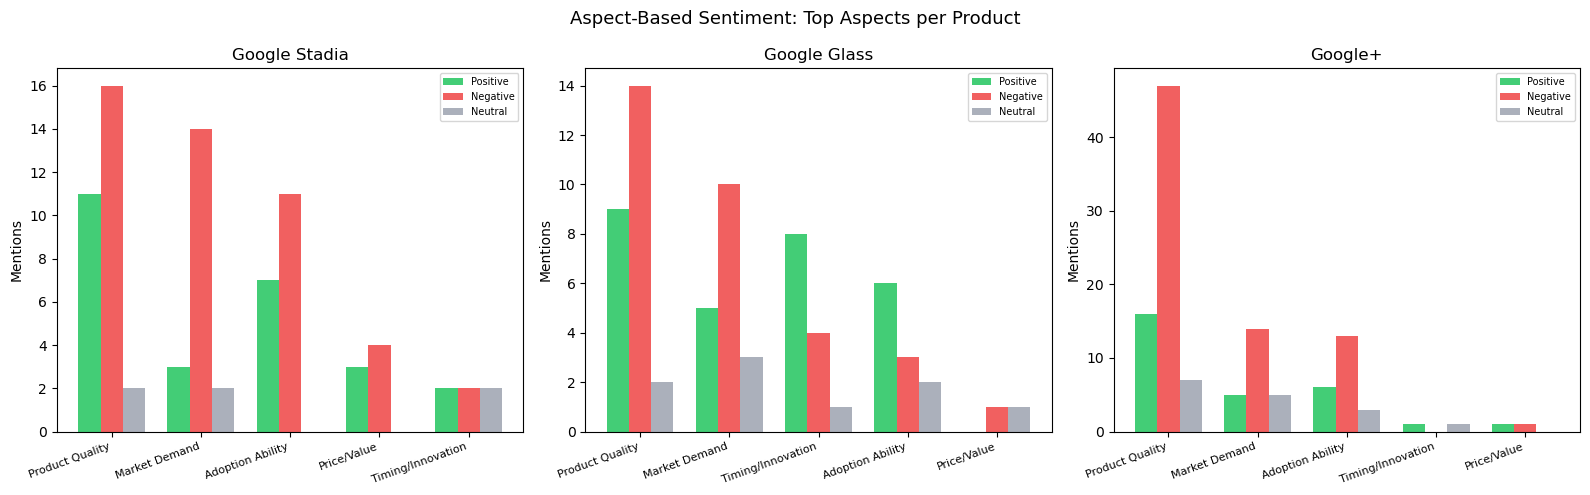

saved absa_aspect_sentiment.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
prod_labels = {'stadia': 'Google Stadia', 'google_glass': 'Google Glass', 'google_plus': 'Google+'}
sentiment_colors = {'Positive': '#22c55e', 'Negative': '#ef4444', 'Neutral': '#9ca3af'}

for ax, prod in zip(axes, ['stadia', 'google_glass', 'google_plus']):
    prod_data = results_df[results_df['product'] == prod]
    top_aspects = prod_data['aspect'].value_counts().head(5).index.tolist()
    pivot = prod_data[prod_data['aspect'].isin(top_aspects)].groupby(
        ['aspect', 'sentiment']).size().unstack(fill_value=0)
    for sent in ['Positive', 'Negative', 'Neutral']:
        if sent not in pivot.columns:
            pivot[sent] = 0
    pivot = pivot.reindex(top_aspects)
    x = range(len(pivot))
    w = 0.25
    ax.bar([i - w for i in x], pivot['Positive'], w, label='Positive', color='#22c55e', alpha=0.85)
    ax.bar(list(x),            pivot['Negative'], w, label='Negative', color='#ef4444', alpha=0.85)
    ax.bar([i + w for i in x], pivot['Neutral'],  w, label='Neutral',  color='#9ca3af', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pivot.index, rotation=20, ha='right', fontsize=8)
    ax.set_title(prod_labels[prod])
    ax.set_ylabel('Mentions')
    ax.legend(fontsize=7)

plt.suptitle('Aspect-Based Sentiment: Top Aspects per Product', fontsize=13)
plt.tight_layout()
plt.savefig('absa_aspect_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved absa_aspect_sentiment.png')

### Before vs After: aspect sentiment shift

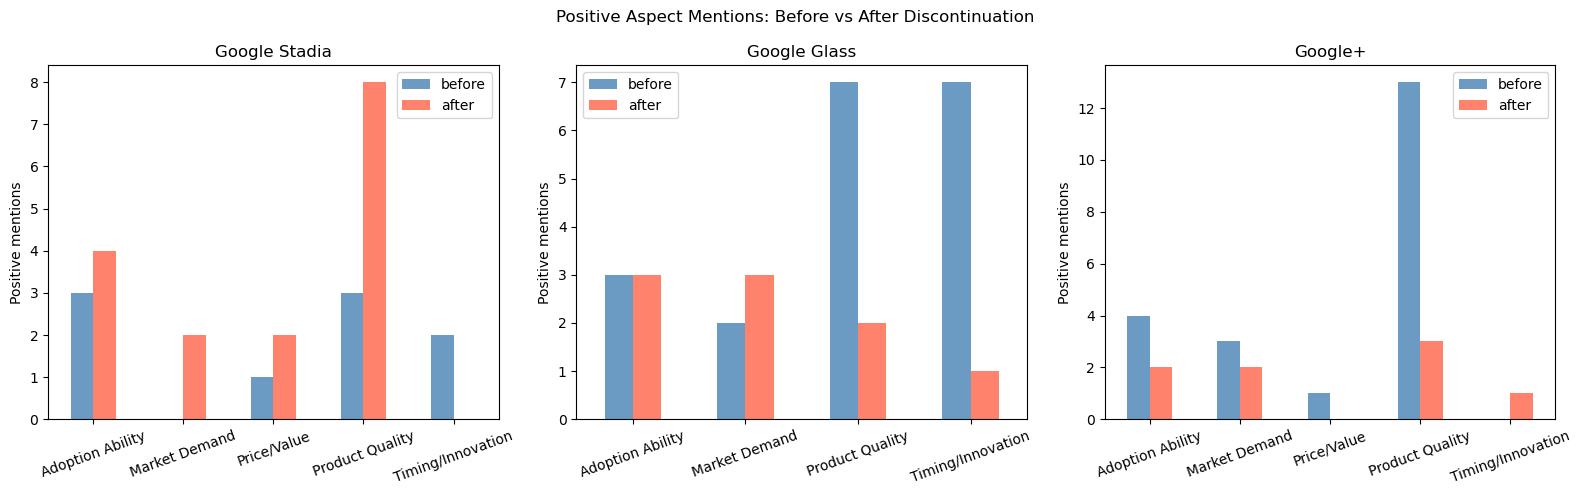

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, prod in zip(axes, ['stadia', 'google_glass', 'google_plus']):
    prod_data = results_df[results_df['product'] == prod]
    period_aspect = prod_data.groupby(['period','aspect','sentiment']).size().reset_index(name='count')
    pos_before = prod_data[(prod_data['period']=='before') & (prod_data['sentiment']=='Positive')]['aspect'].value_counts().head(4)
    pos_after  = prod_data[(prod_data['period']=='after')  & (prod_data['sentiment']=='Positive')]['aspect'].value_counts().head(4)
    combined = pd.DataFrame({'before': pos_before, 'after': pos_after}).fillna(0)
    if combined.empty:
        ax.set_title(prod_labels[prod] + ' (no data)')
        continue
    combined.plot(kind='bar', ax=ax, color=['steelblue','tomato'], alpha=0.8)
    ax.set_title(prod_labels[prod])
    ax.set_ylabel('Positive mentions')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Positive Aspect Mentions: Before vs After Discontinuation', fontsize=12)
plt.tight_layout()
plt.savefig('absa_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary of findings

In [11]:
for prod in ['stadia', 'google_glass', 'google_plus']:
    prod_data = results_df[results_df['product'] == prod]
    top_pos = prod_data[prod_data['sentiment']=='Positive']['aspect'].value_counts().idxmax() if len(prod_data[prod_data['sentiment']=='Positive']) > 0 else 'N/A'
    top_neg = prod_data[prod_data['sentiment']=='Negative']['aspect'].value_counts().idxmax() if len(prod_data[prod_data['sentiment']=='Negative']) > 0 else 'N/A'
    total = len(prod_data)
    print(f'{prod}: {total} triples | hero aspect: {top_pos} | pain point: {top_neg}')

stadia: 79 triples | hero aspect: Product Quality | pain point: Product Quality
google_glass: 69 triples | hero aspect: Product Quality | pain point: Product Quality
google_plus: 120 triples | hero aspect: Product Quality | pain point: Product Quality
